In [1]:
import os
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Mixed Precision
from torch.cuda.amp import autocast, GradScaler

# Scheduler
from torch.optim.lr_scheduler import CosineAnnealingLR

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_DIR = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"

X_train = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_train.npy"))
X_val   = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_val.npy"))
X_test  = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_test.npy"))

Y_train = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_train.npy"))
Y_val   = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_val.npy"))
Y_test  = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_test.npy"))

print("Train :", X_train.shape, Y_train.shape)
print("Val   :", X_val.shape, Y_val.shape)
print("Test  :", X_test.shape, Y_test.shape)

print("\nImage dtype :", X_train.dtype)
print("Mask dtype  :", Y_train.dtype)

print("\nImage Range :", X_train.min(), "to", X_train.max())
print("Mask Values :", np.unique(Y_train))

Train : (1004, 128, 128, 1) (1004, 128, 128, 1)
Val   : (126, 128, 128, 1) (126, 128, 128, 1)
Test  : (130, 128, 128, 1) (130, 128, 128, 1)

Image dtype : float32
Mask dtype  : uint8

Image Range : 0.003921569 to 1.0
Mask Values : [0 1]


In [5]:
shape_train = np.load(os.path.join(DATASET_DIR, "shape_train.npy"))
shape_val   = np.load(os.path.join(DATASET_DIR, "shape_val.npy"))
shape_test  = np.load(os.path.join(DATASET_DIR, "shape_test.npy"))

SHAPE_NAMES = {
    0: "Irregular",
    1: "Oval",
    2: "Lobulated"
}

print("Train :", shape_train.shape)
print("Val   :", shape_val.shape)
print("Test  :", shape_test.shape)

print("\nTraining Distribution")

for label in sorted(np.unique(shape_train)):
    print(f"{SHAPE_NAMES[label]} : {np.sum(shape_train == label)}")

Train : (1004,)
Val   : (126,)
Test  : (130,)

Training Distribution
Irregular : 363
Oval : 322
Lobulated : 319


In [6]:
class MammographyDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]
        mask = self.masks[idx]

        # NumPy -> Torch
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()

        # HWC -> CHW
        image = image.permute(2, 0, 1)
        mask = mask.permute(2, 0, 1)

        return image, mask

In [7]:
train_dataset = MammographyDataset(X_train, Y_train)

image, mask = train_dataset[0]

print("Image Shape :", image.shape)
print("Mask Shape  :", mask.shape)

print("Image dtype :", image.dtype)
print("Mask dtype  :", mask.dtype)

print("Image Min :", image.min().item())
print("Image Max :", image.max().item())

print("Mask Values :", torch.unique(mask))

Image Shape : torch.Size([1, 128, 128])
Mask Shape  : torch.Size([1, 128, 128])
Image dtype : torch.float32
Mask dtype  : torch.float32
Image Min : 0.0117647061124444
Image Max : 0.9058823585510254
Mask Values : tensor([0., 1.])


In [8]:
BATCH_SIZE = 8

train_dataset = MammographyDataset(X_train, Y_train)
val_dataset   = MammographyDataset(X_val, Y_val)
test_dataset  = MammographyDataset(X_test, Y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

g = torch.Generator()
g.manual_seed(42)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=g
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 126
Validation batches : 16
Test batches : 17


In [9]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [10]:
!git clone https://github.com/HuCaoFighting/Swin-Unet.git

Cloning into 'Swin-Unet'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 130 (delta 37), reused 19 (delta 19), pack-reused 67 (from 2)
Receiving objects: 100% (130/130), 58.55 KiB | 7.32 MiB/s, done.
Resolving deltas: 100% (53/53), done.


In [11]:
import os

os.chdir("Swin-Unet")
print("Current Directory:", os.getcwd())

Current Directory: /content/Swin-Unet


In [12]:
!pip install -q timm yacs einops ml-collections

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.1 MB/s eta 0:00:00


In [13]:
import sys

sys.path.append("/content/Swin-Unet")

In [14]:
from networks.vision_transformer import SwinUnet

In [15]:
import os

config_dir = "/content/Swin-Unet/configs"

print(os.listdir(config_dir))

['swin_tiny_patch4_window7_224_lite.yaml']


In [16]:
from config import get_config

In [17]:
import argparse


args = argparse.Namespace()

args.cfg = "/content/Swin-Unet/configs/swin_tiny_patch4_window7_224_lite.yaml"

args.opts = None

args.batch_size = 4

# Required arguments for Swin-Unet config.py
args.zip = False
args.cache_mode = None
args.resume = None
args.accumulation_steps = None
args.use_checkpoint = False
args.amp_opt_level = "O1"
args.tag = "default"
args.eval = False
args.throughput = False

config = get_config(args)

print("Configuration Loaded Successfully")

=> merge config from /content/Swin-Unet/configs/swin_tiny_patch4_window7_224_lite.yaml
Configuration Loaded Successfully


In [18]:
config.defrost()

config.DATA.IMG_SIZE = 128
config.DATA.NUM_CLASSES = 1
config.DATA.BATCH_SIZE = 8

config.MODEL.SWIN.IN_CHANS = 1

config.MODEL.SWIN.WINDOW_SIZE = 4

config.TRAIN.BASE_LR = 1e-4
config.TRAIN.WEIGHT_DECAY = 1e-5
config.SEED = 42


config.freeze()

print("Configuration Modified Successfully")

Configuration Modified Successfully


In [19]:
print("Batch size:", config.DATA.BATCH_SIZE)
print("Learning rate:", config.TRAIN.BASE_LR)
print("Weight decay:", config.TRAIN.WEIGHT_DECAY)
print("Seed:", config.SEED)
print("Window size:", config.MODEL.SWIN.WINDOW_SIZE)

Batch size: 8
Learning rate: 0.0001
Weight decay: 1e-05
Seed: 42
Window size: 4


In [20]:
model = SwinUnet(
    config,
    img_size=128,
    num_classes=1
)

print("Swin-UNet Created Successfully")

SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.2;num_classes:1
---final upsample expand_first---
Swin-UNet Created Successfully


In [21]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params/1e6:.2f} Million"
)

print(
    f"Trainable Parameters: {trainable_params/1e6:.2f} Million"
)

Total Parameters: 27.15 Million
Trainable Parameters: 27.15 Million


In [22]:
import types

def grayscale_forward(self, x):
    logits = self.swin_unet(x)
    return logits


model.forward = types.MethodType(
    grayscale_forward,
    model
)

print("Swin-UNet modified for grayscale input")

Swin-UNet modified for grayscale input


In [23]:
dummy = torch.randn(2,1,128,128)

model.eval()

with torch.no_grad():
    output = model(dummy)

print("Input Shape :", dummy.shape)
print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 1, 128, 128])
Output Shape: torch.Size([2, 1, 128, 128])


In [24]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [25]:
model = model.to(device)

print("Model moved to device")

Model moved to device


In [26]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Optimizer Created")

Optimizer Created


In [27]:
import torch.nn as nn


class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()

        dice = (
            2. * intersection + smooth
        ) / (
            inputs.sum()
            + targets.sum()
            + smooth
        )

        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, inputs, targets):

        bce_loss = self.bce(inputs, targets)
        dice_loss = self.dice(inputs, targets)

        return bce_loss + dice_loss

In [28]:
criterion = BCEDiceLoss()

In [29]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("Scheduler Ready")

Scheduler Ready


In [30]:
images, masks = next(iter(train_loader))

print("Before:")
print(images.shape)
print(masks.shape)

Before:
torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [31]:
images = images.to(device)
masks = masks.to(device)

outputs = model(images)

print("After:")
print(outputs.shape)

After:
torch.Size([8, 1, 128, 128])


In [32]:
loss = criterion(outputs, masks)

print("Loss:", loss.item())

Loss: 1.6275092363357544


In [33]:
epochs = 80

best_val_loss = float("inf")

train_losses = []
val_losses = []

train_dices = []
val_dices = []

train_ious = []
val_ious = []

patience = 15
counter = 0

In [34]:
import torch


def calculate_metrics(outputs, masks, threshold=0.5):

    # Convert logits to probabilities
    probs = torch.sigmoid(outputs)

    # Binary prediction
    preds = (probs > threshold).float()


    # Flatten
    preds = preds.view(-1)
    masks = masks.view(-1)


    # Intersection
    intersection = (preds * masks).sum()


    # Dice
    dice = (
        (2.0 * intersection + 1e-7)
        /
        (preds.sum() + masks.sum() + 1e-7)
    )


    # IoU
    union = (
        preds.sum()
        + masks.sum()
        - intersection
    )

    iou = (
        (intersection + 1e-7)
        /
        (union + 1e-7)
    )


    return (
        dice.item(),
        iou.item()
    )

In [35]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

dice, iou = calculate_metrics(outputs, masks)

print("Dice:", dice)
print("IoU :", iou)

Dice: 0.0849943608045578
IoU : 0.044383347034454346


In [36]:
for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*40)

    model.train()

    running_train_loss = 0
    running_train_dice = 0
    running_train_iou = 0


    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )


        loss.backward()

        optimizer.step()


        running_train_loss += loss.item()


        dice, iou = calculate_metrics(
            outputs,
            masks
        )

        running_train_dice += dice
        running_train_iou += iou



    train_loss = running_train_loss / len(train_loader)

    train_dice = running_train_dice / len(train_loader)

    train_iou = running_train_iou / len(train_loader)


    model.eval()

    running_val_loss = 0
    running_val_dice = 0
    running_val_iou = 0


    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)


            outputs = model(images)


            loss = criterion(
                outputs,
                masks
            )


            running_val_loss += loss.item()


            dice, iou = calculate_metrics(
                outputs,
                masks
            )

            running_val_dice += dice
            running_val_iou += iou



    val_loss = running_val_loss / len(val_loader)

    val_dice = running_val_dice / len(val_loader)

    val_iou = running_val_iou / len(val_loader)



    # Scheduler update

    scheduler.step(val_loss)

    # Store history

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_dices.append(train_dice)
    val_dices.append(val_dice)

    train_ious.append(train_iou)
    val_ious.append(val_iou)



    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Train Dice : {train_dice:.4f} | "
        f"Train IoU : {train_iou:.4f}"
    )


    print(
        f"Val Loss   : {val_loss:.4f} | "
        f"Val Dice   : {val_dice:.4f} | "
        f"Val IoU    : {val_iou:.4f}"
    )



    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_swin_unet.pth"
        )

        counter = 0

        print("✓ Best model saved")

    else:

        counter += 1

        print(
            f"Early stopping counter: {counter}/{patience}"
        )


    if counter >= patience:

        print("Early stopping triggered")

        break


Epoch 1/80
----------------------------------------
Train Loss : 0.9472 | Train Dice : 0.2348 | Train IoU : 0.1501
Val Loss   : 0.5866 | Val Dice   : 0.5811 | Val IoU    : 0.4141
✓ Best model saved

Epoch 2/80
----------------------------------------
Train Loss : 0.5874 | Train Dice : 0.5738 | Train IoU : 0.4109
Val Loss   : 0.4831 | Val Dice   : 0.6456 | Val IoU    : 0.4807
✓ Best model saved

Epoch 3/80
----------------------------------------
Train Loss : 0.5189 | Train Dice : 0.6233 | Train IoU : 0.4598
Val Loss   : 0.4351 | Val Dice   : 0.6887 | Val IoU    : 0.5272
✓ Best model saved

Epoch 4/80
----------------------------------------
Train Loss : 0.5000 | Train Dice : 0.6376 | Train IoU : 0.4756
Val Loss   : 0.4016 | Val Dice   : 0.7107 | Val IoU    : 0.5548
✓ Best model saved

Epoch 5/80
----------------------------------------
Train Loss : 0.4740 | Train Dice : 0.6565 | Train IoU : 0.4956
Val Loss   : 0.4068 | Val Dice   : 0.7073 | Val IoU    : 0.5506
Early stopping counter: 

In [37]:
print("Best Validation Loss:", best_val_loss)

best_epoch = val_losses.index(best_val_loss) + 1

print("Best Epoch:", best_epoch)
print("Best Validation Dice:", val_dices[best_epoch-1])
print("Best Validation IoU:", val_ious[best_epoch-1])

Best Validation Loss: 0.17790362611413002
Best Epoch: 39
Best Validation Dice: 0.8683930300176144
Best Validation IoU: 0.7679567635059357


In [38]:
checkpoint = torch.load(
    "/content/Swin-Unet/best_swin_unet.pth",
    map_location="cpu"
)

print(type(checkpoint))
print(len(checkpoint))
print(list(checkpoint.keys())[:10])

<class 'collections.OrderedDict'>
238
['swin_unet.patch_embed.proj.weight', 'swin_unet.patch_embed.proj.bias', 'swin_unet.patch_embed.norm.weight', 'swin_unet.patch_embed.norm.bias', 'swin_unet.layers.0.blocks.0.norm1.weight', 'swin_unet.layers.0.blocks.0.norm1.bias', 'swin_unet.layers.0.blocks.0.attn.relative_position_bias_table', 'swin_unet.layers.0.blocks.0.attn.relative_position_index', 'swin_unet.layers.0.blocks.0.attn.qkv.weight', 'swin_unet.layers.0.blocks.0.attn.qkv.bias']


In [39]:
torch.save(
    model.state_dict(),
    "best_swin_unet_bce_dice_seed42.pth"
)

In [41]:
save_path = "/content/drive/.shortcut-targets-by-id/1__Vswd3cxzZ3JpClOjiLWhZl6VNIpkoT/Mammogram_Shape_Preprocess/SwinUNet_BCEDice_final_best.pth"

torch.save(model.state_dict(), save_path)

In [42]:
test_loss = 0

test_dice = 0
test_iou = 0

num_batches = 0

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        dice, iou = calculate_metrics(
            outputs,
            masks
        )

        test_loss += loss.item()
        test_dice += dice
        test_iou += iou

        num_batches += 1


test_loss /= num_batches
test_dice /= num_batches
test_iou /= num_batches

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")

Test Loss : 0.2719
Test Dice : 0.8042
Test IoU  : 0.6780


In [43]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

model.eval()

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_masks.extend(
            masks.numpy().flatten()
        )


precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.7709
Recall    : 0.8267
F1 Score  : 0.7978


In [44]:
import pandas as pd

results = pd.DataFrame({

    "Metric": [
        "Loss",
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        test_loss,
        test_dice,
        test_iou,
        precision,
        recall,
        f1
    ]

})

results

,Metric,Value
0,Loss,0.271910
1,Dice,0.804154
2,IoU,0.678031
3,Precision,0.770866
4,Recall,0.826685
5,F1 Score,0.797801


In [45]:
results.to_csv(
    "SwinUNet_Test_Results.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully


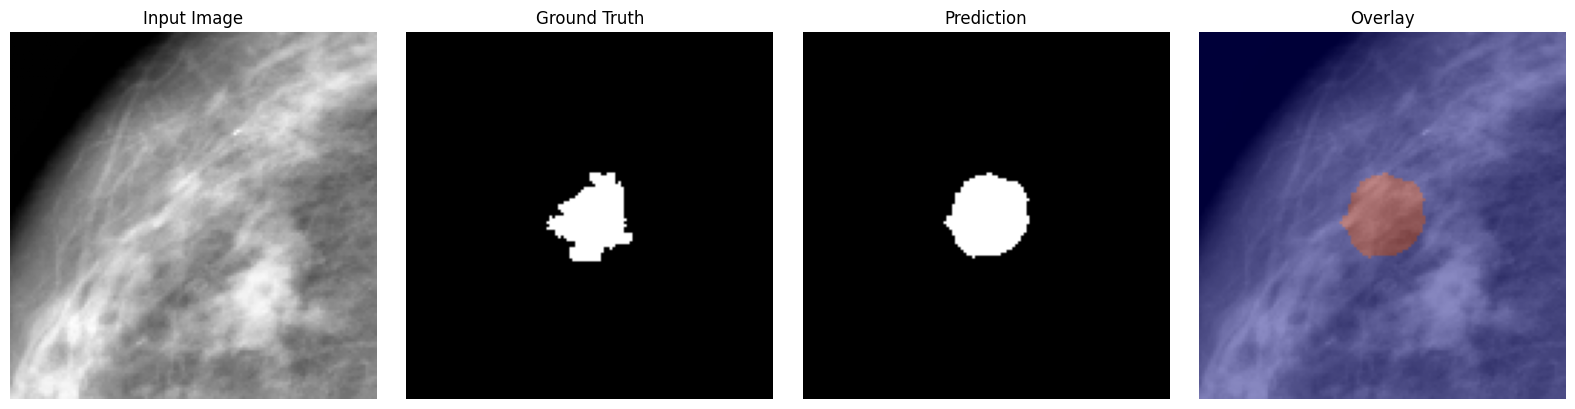

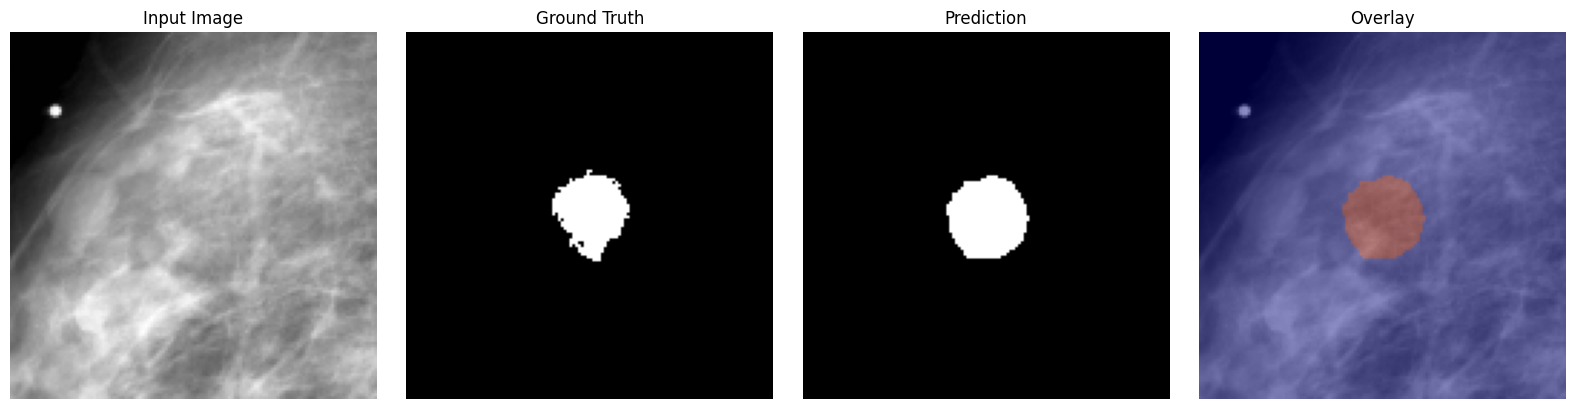

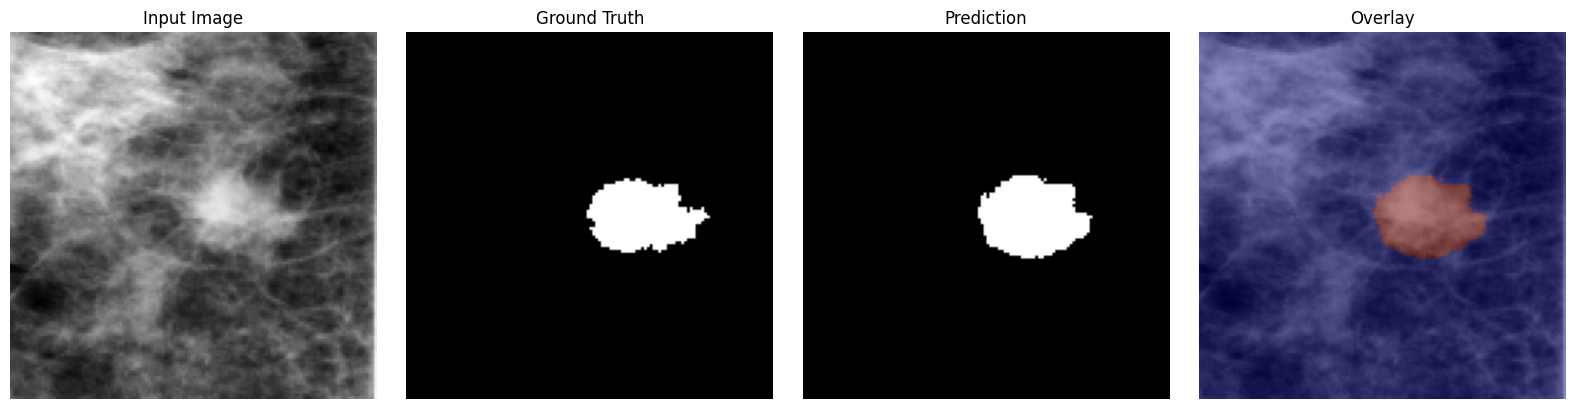

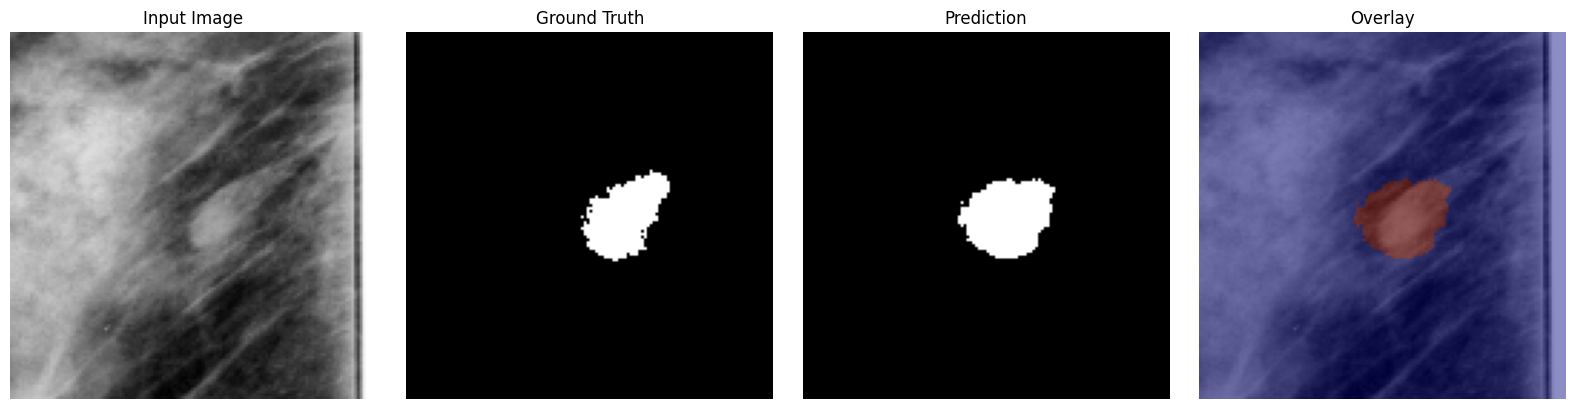

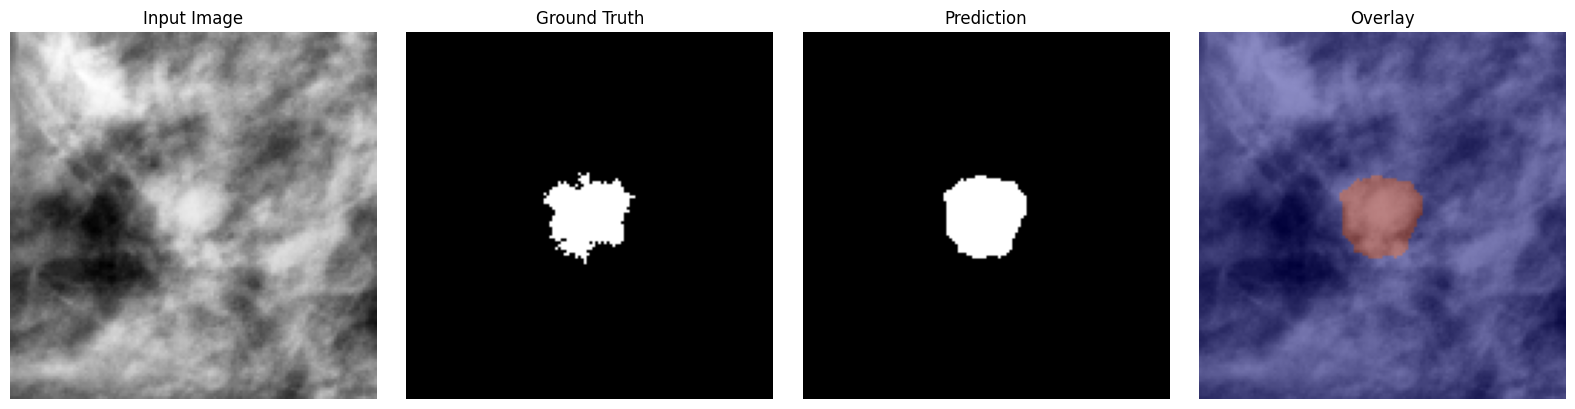

In [46]:
import random
import matplotlib.pyplot as plt

model.eval()

num_samples = 5

indices = random.sample(range(len(test_dataset)), num_samples)

with torch.no_grad():

    for idx in indices:

        image, mask = test_dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        prediction = model(input_tensor)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        image_np = image.squeeze().cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_np = prediction.squeeze().cpu().numpy()

        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(image_np, cmap="gray")
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(image_np, cmap="gray")
        plt.imshow(pred_np, alpha=0.45, cmap="jet")
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

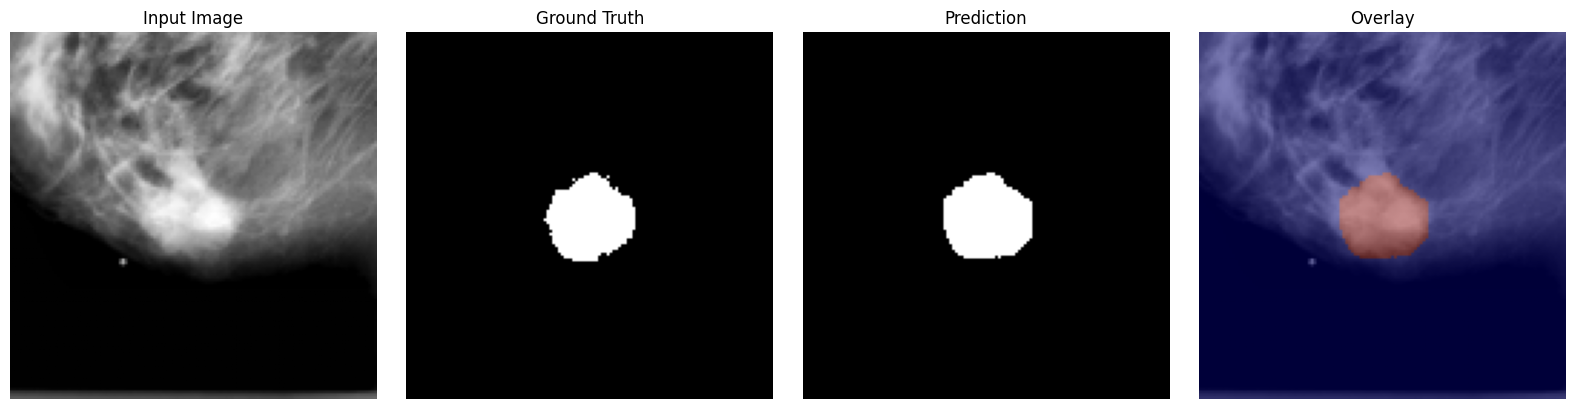

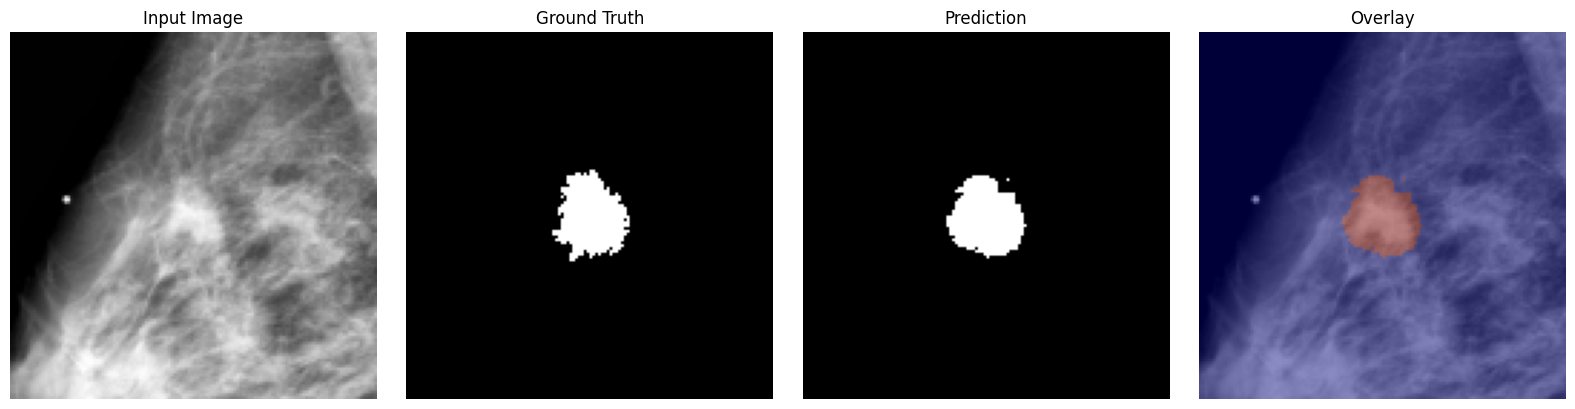

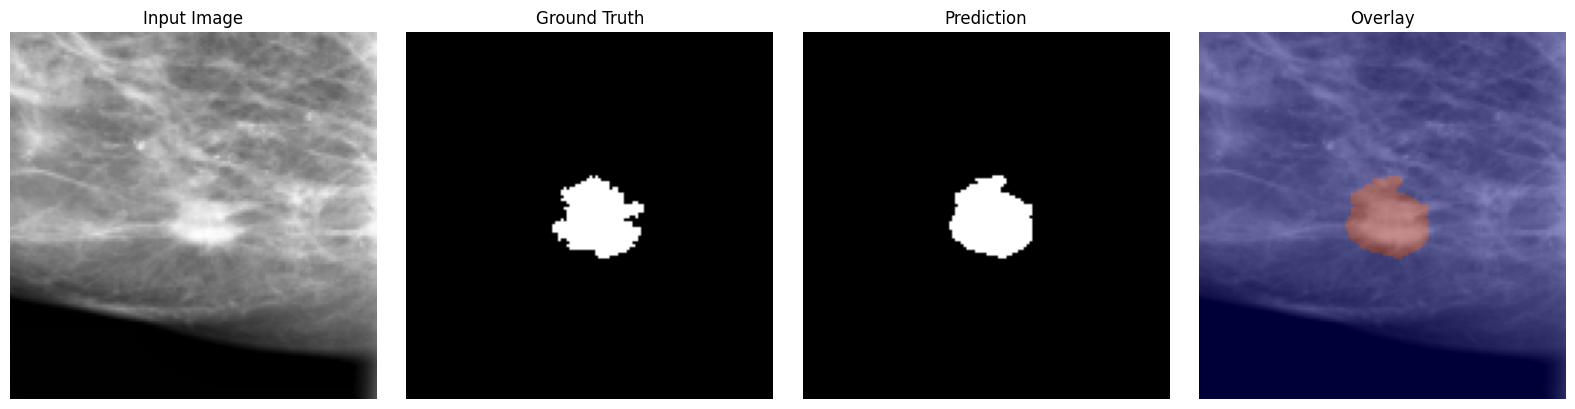

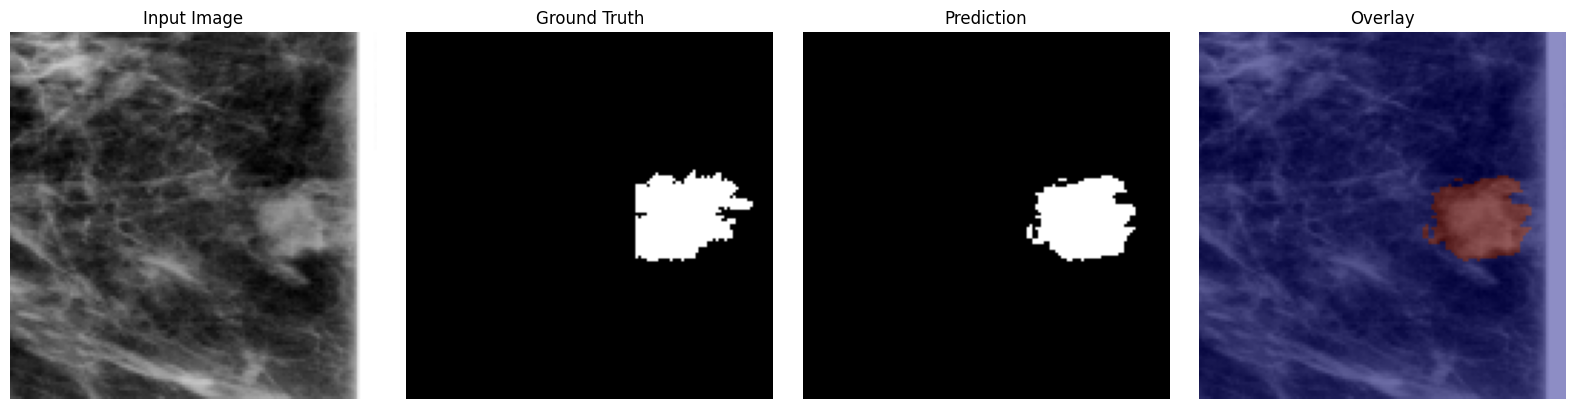

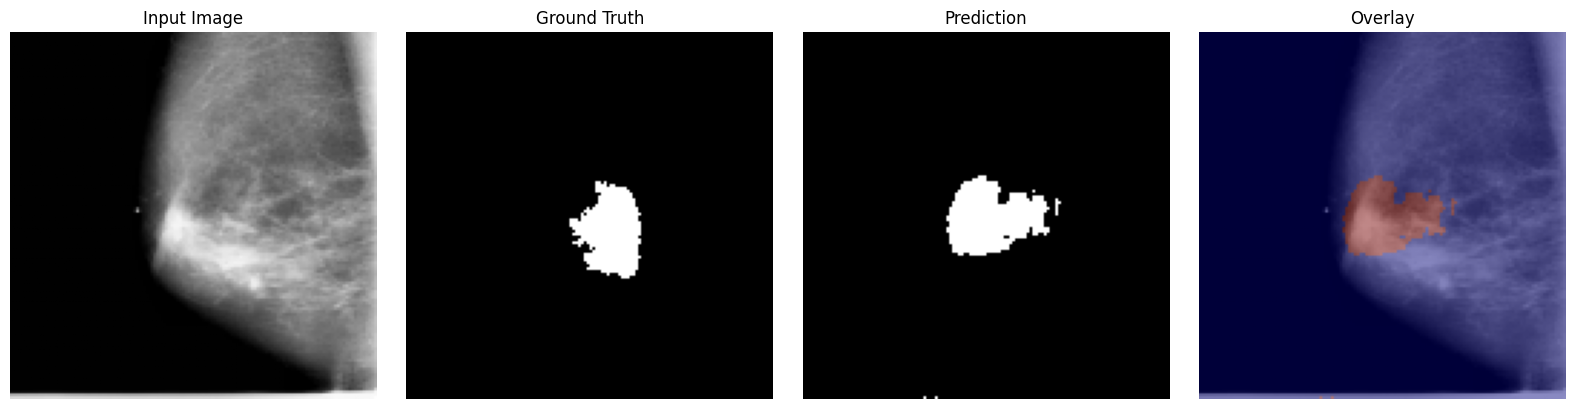

In [47]:
import random
import matplotlib.pyplot as plt

model.eval()

num_samples = 5

indices = random.sample(range(len(test_dataset)), num_samples)

with torch.no_grad():

    for idx in indices:

        image, mask = test_dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        prediction = model(input_tensor)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        image_np = image.squeeze().cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_np = prediction.squeeze().cpu().numpy()

        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(image_np, cmap="gray")
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(image_np, cmap="gray")
        plt.imshow(pred_np, alpha=0.45, cmap="jet")
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [51]:
from torch.utils.data import DataLoader

# ── Non-shuffled loaders so batch order matches shape_train/val/test order ──
eval_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
eval_val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
eval_test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


def evaluate_dice_iou_by_shape(loader, shape_labels, model, device):
    """loader must be shuffle=False. Returns {shape_label: (avg_dice, avg_iou)}"""
    model.eval()

    dice_sum, iou_sum, count = {}, {}, {}
    idx = 0

    with torch.no_grad():
        for images, masks in loader:
            batch_len = images.shape[0]
            batch_shapes = shape_labels[idx: idx + batch_len]
            idx += batch_len

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            for i in range(batch_len):
                s = int(batch_shapes[i])

                p = preds[i].view(-1)
                m = masks[i].view(-1)

                intersection = (p * m).sum()
                dice = (2.0 * intersection + 1e-7) / (p.sum() + m.sum() + 1e-7)
                union = p.sum() + m.sum() - intersection
                iou = (intersection + 1e-7) / (union + 1e-7)

                dice_sum[s] = dice_sum.get(s, 0.0) + dice.item()
                iou_sum[s]  = iou_sum.get(s, 0.0) + iou.item()
                count[s]    = count.get(s, 0) + 1

    assert idx == len(shape_labels), "loader/shape_labels length mismatch"

    return {s: (dice_sum[s] / count[s], iou_sum[s] / count[s]) for s in count}


# ── Run on all three splits ──────────────────────────────────────────
train_shape_metrics = evaluate_dice_iou_by_shape(eval_train_loader, shape_train, model, device)
val_shape_metrics   = evaluate_dice_iou_by_shape(eval_val_loader,   shape_val,   model, device)
test_shape_metrics  = evaluate_dice_iou_by_shape(eval_test_loader,  shape_test,  model, device)


# ── Build the comparison table ───────────────────────────────────────
rows = []
for label in sorted(SHAPE_NAMES.keys()):
    train_dice, train_iou = train_shape_metrics.get(label, (None, None))
    val_dice, val_iou     = val_shape_metrics.get(label, (None, None))
    test_dice, test_iou   = test_shape_metrics.get(label, (None, None))

    rows.append({
        "Shape": SHAPE_NAMES[label],
        "Train Dice": round(train_dice, 4) if train_dice is not None else None,
        "Val Dice":   round(val_dice, 4) if val_dice is not None else None,
        "Test Dice":  round(test_dice, 4) if test_dice is not None else None,
        "Train IoU":  round(train_iou, 4) if train_iou is not None else None,
        "Val IoU":    round(val_iou, 4) if val_iou is not None else None,
        "Test IoU":   round(test_iou, 4) if test_iou is not None else None,
    })

shape_comparison_df = pd.DataFrame(rows)
shape_comparison_df

,Shape,Train Dice,Val Dice,Test Dice,Train IoU,Val IoU,Test IoU
0,Irregular,0.8793,0.8723,0.7893,0.7895,0.7768,0.6813
1,Oval,0.8763,0.8662,0.7560,0.7867,0.7718,0.6574
2,Lobulated,0.8901,0.8607,0.8894,0.8054,0.7648,0.8061
